In [1]:
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt

import coqui

Hartree_eV = 27.211386245988

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


Starting serial run at: 2026-05-17 15:54:30.291856


## Ab Initio GW+EDMFT for Quantum Materials

This tutorial provides an introduction ot the ab initio GW+EDMFT method for quantum materials. 

This tutorial will cover:
1. Initializing and executing a GW+EDMFT calculation

2. Important parameters and settings when performing GW+EDMFT calculations

3. Important observales/results obtained from GW+EDMFT calculations

## Realizing GW+EDMFT: CoQuí and TRIQS

<figure style="text-align: center;">
 <img src="../../images/gw_edmft_workflow.png" alt="GW+EDMFT workflow using CoQuí + TRIQS" width="65%">
 <figcaption>GW+EDMFT workflow using CoQuí + TRIQS.</figcaption>
</figure>

[Brief overivew on GW+EDMFT methodology and the physics it captures. Then describe the workflow for a self-consistent GW+EDMFT calculation and how CoQuí and TRIQS work together to realize it.] 

The workflow is split between CoQuí (orange boxes) and TRIQS (blue boxes), each with distinct responsibilities.

### Why CoQuí

1. Efficient ab initio GW with full frequency dependence in the full Hilbert space
2. Downfolding routines for projecting lattice $G$ and $W$ into MLWF subspaces and building impurity actions
3. Upfolding routines for embedding impurity corrections back into the lattice problem

[Brief decription on ModEST and CT-SEG impurity solver. We may need more details on CT-QMC solver since CoQui's users may have zero experience with TRIQS and its solvers, such as in [the solid_dmft tutorial](https://github.com/TRIQS/tutorials/blob/3.3.x/AbinitioDMFT/01-solid_dmft.ipynb).]
### Why TRIQS-ModEST and CT-SEG

1. Flexible mapping from MLWFs to impurity subspaces
2. Support for multiple impurities
3. Block structures and symmetry constraints that reduce cost and improve stability

Together, CoQuí handles full-basis tasks (GW, downfolding, upfolding), while TRIQS handles impurity-space construction and solution.

## Test system: NiO (paramagnetic charge-transfer insulator)

<figure style="text-align: center;">
 <img src="../../images/nio_gw_edmft_summary.png" alt="NiO" width="80%">
</figure>

Throughout this notebook, we use paramagnetic NiO as a representative correlated material.

**Physics background**
- NiO is a classic charge-transfer insulator with strong Ni 3d–O 2p hybridization.
- This makes double counting a central challenge in DFT+DMFT-type workflows.
- DFT and GW alone do not fully capture the insulating state.
- The Mott gap opens primarily in Ni $e_g$ orbitals and requires local correlations (DMFT/EDMFT).

**Starting point in this notebook**
- A pre-computed self-consistent GW solution for NiO
- MLWFs from a large window including Ni $d$ and O $p$ states (8 orbitals total)


In [2]:
# TODO run a python script to copy the following input files to here
# - `../../data/qe_inputs/nio/555/mlwf_dp/nio.mlwf.h5`: MLWFs for Ni $d$ + O $p$
# - `../../data/coqui/nio/555/nio.mbpt.h5`: pre-computed GW solution

### Section 1: GW+EDMFT 

[This section will focus on introducing `coqui.run_gw_edmft` function and its input/output. We will then show how to use it to run a self-consistent GW+EDMFT calculation for NiO, and analyze the results (spectral functions, self-energies, etc.) to see how the insulating state emerges.]

In [2]:
dmft_h5 = "/mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/svo_666/coqui/02_gw_edmft_t2g/svo.dmft.h5"
iaft = coqui.IAFT.from_coqui_chkpt(dmft_h5)

niter, solver_inputs = 75, []
for it in range(niter):
    inp = coqui.dmft.read_impurity_chkpt(dmft_h5, read="inputs", iteration=it)
    solver_inputs.append(inp[0])

solver_results = []
for it in range(niter):
    res = coqui.dmft.read_impurity_chkpt(dmft_h5, read="results", iteration=it)
    solver_results.append(res[0])

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/svo_666/coqui/02_gw_edmft_t2g/svo.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/svo_666/coqui/02_gw_edmft_t2g/svo.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/svo_666/coqui/02_gw_edmft_t2g/svo.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/svo_666/coqui/02_gw_edmft_t2g/svo.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/svo_666/coqui/02_gw_edmft_t2g/svo.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/svo_666/coqui/02_gw_edmft_t2g/svo.dmft.h5
impurity list = [0]

Reading impurity checkpoint file: /mnt/home/cyeh/ceph/coqui-tutorial/q

#### 🔹 Local correlation functions

[TODO Check the dmft checkpoint file and visualize the local Green's function and local screened interaction $G_{\mathrm{loc}}$ and $W_{\mathrm{loc}}$.]

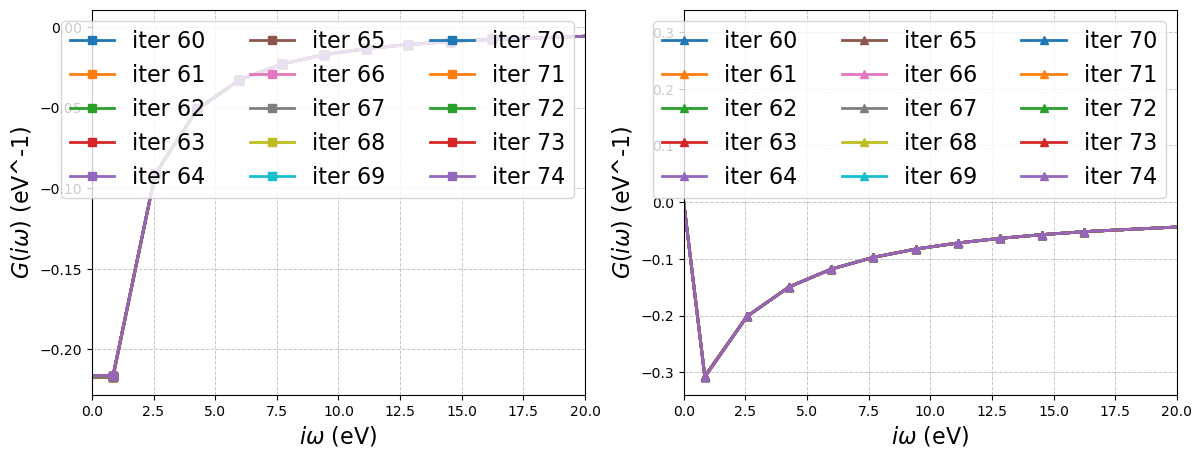

In [4]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 60
for i in range(offset, len(solver_inputs),1):
    G_iw_t2g = iaft.tau_to_w(solver_inputs[i]['Gloc_t'][0], 'f')

    ax[0].plot(iw_mesh_f, G_iw_t2g[:,0,0].real/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    #ax[0].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].real/Hartree_eV, 
    #        linestyle='--', marker='o', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_f, G_iw_t2g[:,0,0].imag/Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    #ax[1].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].imag/Hartree_eV, 
    #        linestyle='--', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$G(i\omega)$ (eV^-1)", fontsize=16)
    ax[i].legend(ncol=3, loc=1, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

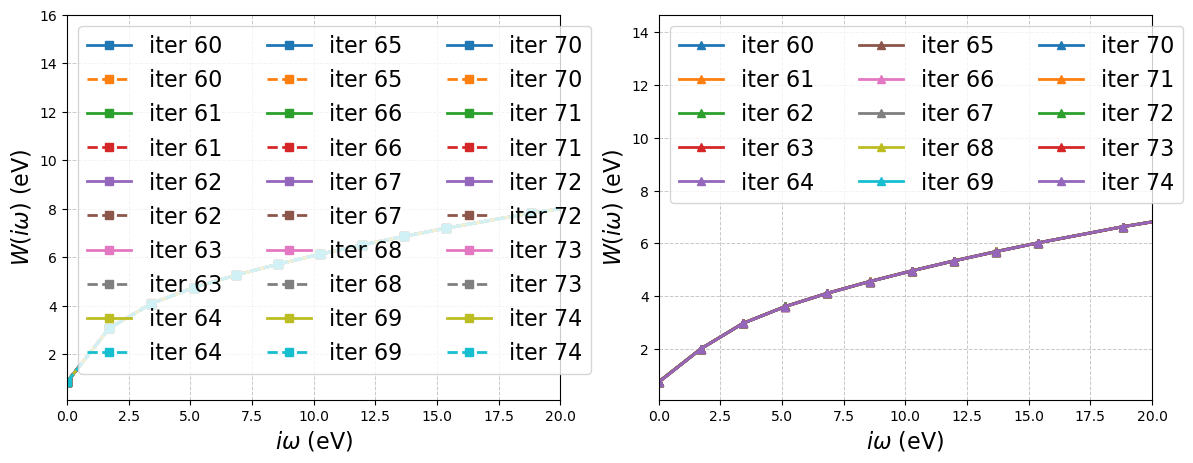

In [5]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 60
for i in range(offset, len(solver_inputs),1):
    W_iw = iaft.tau_to_w_phsym(solver_inputs[i]['Wloc_t'], 'boson')
    ax[0].plot(iw_mesh_b, (W_iw[:,0,0,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0].plot(iw_mesh_b, (solver_results[i]['W_iw_data'][0][:,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='--', marker='s', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (W_iw[:,0,0,1,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    #ax[1].plot(iw_mesh_b, (solver_results[i]['W_iw_data'][0][:,0,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
    #        linestyle='--', marker='s', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    #ax[i].set_ylim(-1, 10)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$W(i\omega)$ (eV)", fontsize=16)
    ax[i].legend(ncol=3, loc=2, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

#### 🔹 Impurity problem - Weiss fields 
[TODO Check the dmft checkpoint file and visualize the impurity Weiss fields $\mathcal{G}$ and $\mathcal{U}$.]

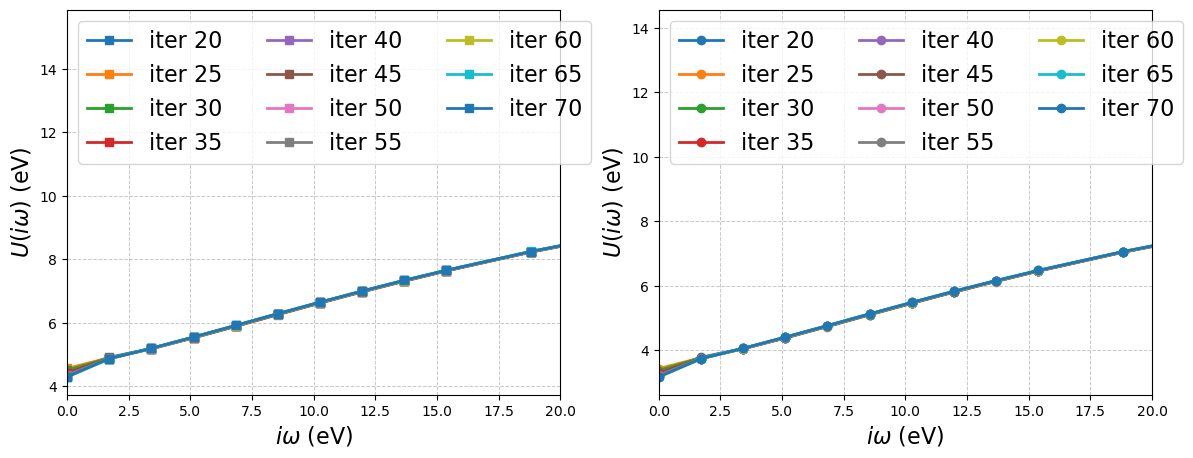

In [8]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 20
for i in range(offset,len(solver_inputs),5):
    ax[0].plot(iw_mesh_b, (solver_inputs[i]['u_weiss_iw'][:,0,0,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (solver_inputs[i]['u_weiss_iw'][:,0,0,1,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='-', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    #ax[i].set_ylim(2, 18)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$U(i\omega)$ (eV)", fontsize=16)
    ax[i].legend(ncol=3, loc=2, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

#### 🔹 Impurity solution
[TODO Check the dmft checkpoint file and visualize the impurity solutions $\Sigma_{\mathrm{imp}}$ and $\Pi_{\mathrm{imp}}$, and compare to the double counting solution.]

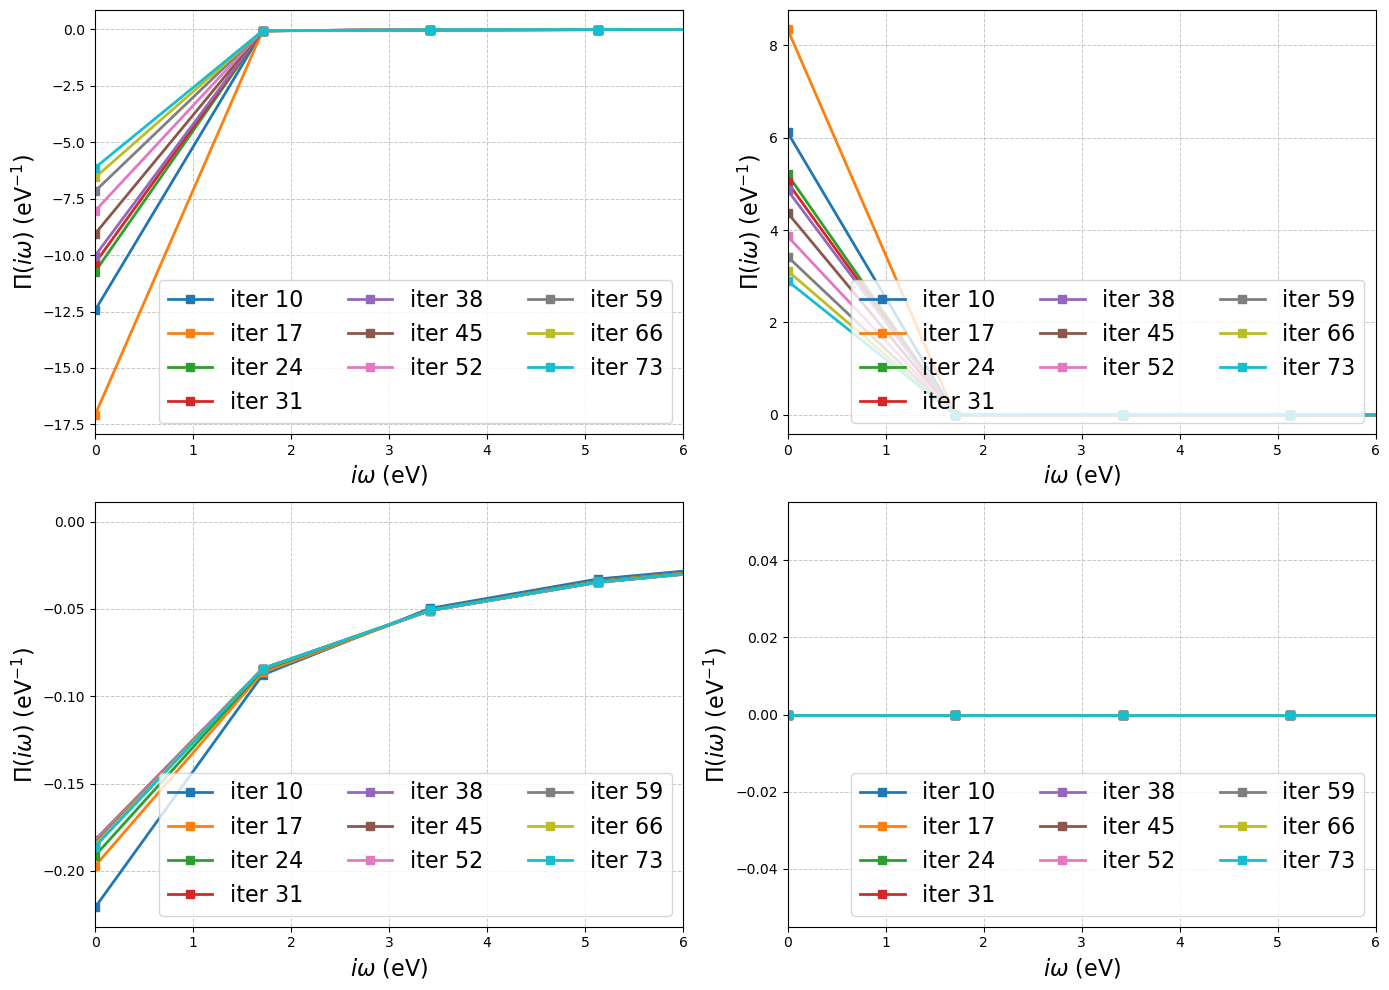

In [9]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(14,10), dpi=100)

offset = 10
for i in range(offset,len(solver_results), 7):
    ax[0,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,0,0].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,0,1].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,0,0].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,0,1].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')

for ij in range(4):
    i = ij//2
    j = ij%2
    ax[i,j].set_xlim(0, 6)
    ax[i,j].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,j].set_ylabel("$\Pi(i\omega)$ (eV$^{-1}$)", fontsize=16)
    ax[i,j].legend(ncol=3, loc=4, fontsize=16)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.tight_layout()

In [10]:
for i in range(len(solver_results)):
    vhf_dc = solver_results[i]['Sigma_infty_dc'][0][0,0]
    vhf_imp = solver_results[i]['Sigma_infty'][0][0,0]
    print(f"Vhf imp = {vhf_imp.real}, Vhf dc = {vhf_dc.real}, diff = {vhf_imp.real-vhf_dc.real}")

Vhf imp = 0.041444477902132085, Vhf dc = 0.041782004437817044, diff = -0.0003375265356849594
Vhf imp = 0.04601494972889761, Vhf dc = 0.047083950190982195, diff = -0.0010690004620845864
Vhf imp = 0.05545223403807601, Vhf dc = 0.05493389445759145, diff = 0.0005183395804845628
Vhf imp = 0.0679761407841695, Vhf dc = 0.06775161919898805, diff = 0.00022452158518145027
Vhf imp = 0.08042335257721317, Vhf dc = 0.08067146721777617, diff = -0.00024811464056299914
Vhf imp = 0.09136974389648113, Vhf dc = 0.09131643577448899, diff = 5.330812199214052e-05
Vhf imp = 0.10091068306853035, Vhf dc = 0.099868548241804, diff = 0.0010421348267263542
Vhf imp = 0.10555601166323512, Vhf dc = 0.10700278138970148, diff = -0.0014467697264663598
Vhf imp = 0.1046791911703231, Vhf dc = 0.10516882700747872, diff = -0.0004896358371556248
Vhf imp = 0.10384252254822353, Vhf dc = 0.10351613976869851, diff = 0.00032638277952501404
Vhf imp = 0.10275761888899945, Vhf dc = 0.10162383836263536, diff = 0.001133780526364092
Vhf 

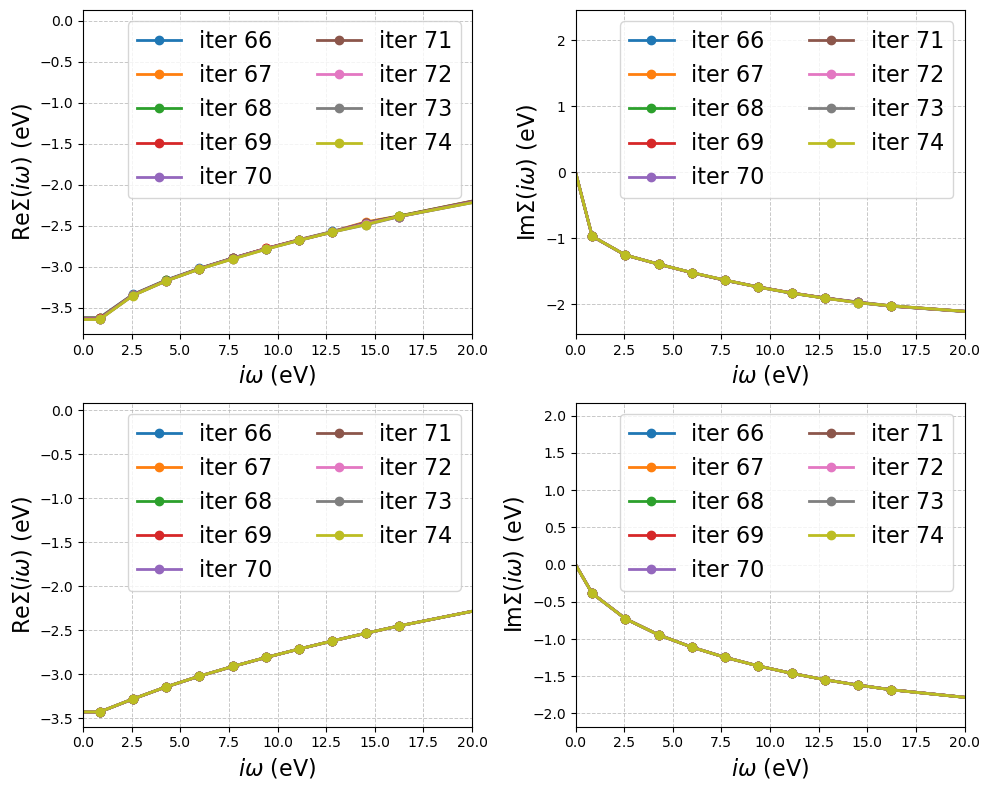

In [13]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(10,8), dpi=100)
offset = 66
for i in range(offset,len(solver_results), 1):
    ax[0,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i,0].set_xlim(0, 20)
    ax[i,0].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,0].set_ylabel("Re$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,0].legend(loc=1, ncol=2, fontsize=16)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

for i in range(2):
    ax[i,1].set_xlim(0, 20)
    #ax[i,1].set_ylim(-2.5, 0.0)
    ax[i,1].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,1].set_ylabel("Im$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,1].legend(loc=1, ncol=2, fontsize=16)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()